# Chapter 12.5: On-Device & Edge Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand the constraints of on-device recommendation (memory, compute, latency)
2. Apply model compression techniques: pruning, quantization, and knowledge distillation
3. Implement on-device personalization with local fine-tuning
4. Design privacy-preserving recommendation using on-device computation
5. Build a split inference system (device handles personalization, server handles base model)
6. Evaluate trade-offs between model size, accuracy, and latency
7. Implement federated learning for decentralized recommendation

## Prerequisites

- Understanding of neural recommendation models (Parts 5-6)
- Familiarity with model training and optimization
- Basic knowledge of privacy concerns in ML
- PyTorch proficiency

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part12/chapter_12.5_on_device.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part12/chapter_12.5_on_device.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time
import copy
from collections import defaultdict

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cpu')

print("All imports successful!")

All imports successful!


## 1. On-Device Recommendation Constraints

Mobile devices have strict constraints:

| Constraint | Typical Limit |
|-----------|---------------|
| Model size | < 10 MB |
| RAM usage | < 50 MB |
| Inference latency | < 50 ms |
| Battery impact | Minimal |
| No network | Must work offline |

> **💡 Concept:** On-device recommendation is driven by two forces: (1) **privacy** — user data
> never leaves the device, and (2) **latency** — local inference is faster than a network round-trip.
> The challenge is fitting a capable model into these constraints.

In [2]:
# Generate synthetic data
def generate_data(n_users=500, n_items=1000, n_interactions=20000, embed_dim=64):
    user_factors = np.random.randn(n_users, embed_dim) * 0.3
    item_factors = np.random.randn(n_items, embed_dim) * 0.3
    
    interactions = []
    for _ in range(n_interactions):
        u = np.random.randint(0, n_users)
        i = np.random.randint(0, n_items)
        score = np.dot(user_factors[u], item_factors[i])
        label = 1 if score + np.random.randn() * 0.5 > 0 else 0
        interactions.append((u, i, label))
    
    return interactions, user_factors, item_factors

interactions, true_user_factors, true_item_factors = generate_data()

class RecDataset(Dataset):
    def __init__(self, data):
        self.users = torch.tensor([d[0] for d in data], dtype=torch.long)
        self.items = torch.tensor([d[1] for d in data], dtype=torch.long)
        self.labels = torch.tensor([d[2] for d in data], dtype=torch.float)
    def __len__(self): return len(self.users)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

split = int(0.8 * len(interactions))
train_loader = DataLoader(RecDataset(interactions[:split]), batch_size=256, shuffle=True)
val_loader = DataLoader(RecDataset(interactions[split:]), batch_size=256)
print(f"Train: {split}, Val: {len(interactions)-split}")

Train: 16000, Val: 4000


## 2. Teacher Model (Full-Size Server Model)

First, we train a full-size "teacher" model that would run on the server.
This represents our accuracy upper bound.

In [3]:
class TeacherRecModel(nn.Module):
    """Full-size recommendation model (server-side)."""
    def __init__(self, n_users=500, n_items=1000, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, users, items):
        u = self.user_emb(users)
        i = self.item_emb(items)
        x = torch.cat([u, i], dim=-1)
        return self.mlp(x).squeeze(-1)

def train_model(model, train_loader, val_loader, n_epochs=15, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'val_auc': []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for users, items, labels in train_loader:
            pred = model(users, items)
            loss = criterion(pred, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for users, items, labels in val_loader:
                pred = torch.sigmoid(model(users, items))
                all_preds.extend(pred.numpy())
                all_labels.extend(labels.numpy())
        
        # Simple AUC approximation
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        pos = all_preds[all_labels == 1]
        neg = all_preds[all_labels == 0]
        auc = np.mean([np.mean(pos > n) for n in neg]) if len(pos) > 0 and len(neg) > 0 else 0.5
        
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_auc'].append(auc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1} - Loss: {total_loss/len(train_loader):.4f}, AUC: {auc:.4f}")
    
    return history

teacher = TeacherRecModel()
teacher_history = train_model(teacher, train_loader, val_loader)

def get_model_size(model):
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 * 1024)  # MB

print(f"\nTeacher model size: {get_model_size(teacher):.2f} MB")
print(f"Teacher parameters: {sum(p.numel() for p in teacher.parameters()):,}")

Epoch 5 - Loss: 0.6632, AUC: 0.4926


Epoch 10 - Loss: 0.5755, AUC: 0.4945


Epoch 15 - Loss: 0.4891, AUC: 0.5025

Teacher model size: 0.52 MB
Teacher parameters: 137,345


## 3. Knowledge Distillation

Train a smaller "student" model to mimic the teacher's predictions:

$$\mathcal{L}_{\text{distill}} = \alpha \cdot \text{KL}(p_T \| p_S) + (1-\alpha) \cdot \mathcal{L}_{\text{task}}$$

where $p_T$ and $p_S$ are the teacher and student predictions, softened by temperature $\tau$:

$$p_T = \sigma(z_T / \tau), \quad p_S = \sigma(z_S / \tau)$$

> **🔑 Pro Tip:** The teacher's "soft labels" contain richer information than hard labels.
> For example, if the teacher gives 0.8 for item A and 0.3 for item B, the student learns
> that A is much better than B — information lost with hard labels (1 vs 0).

In [4]:
class StudentRecModel(nn.Module):
    """Compressed student model for on-device deployment."""
    def __init__(self, n_users=500, n_items=1000, embed_dim=16, hidden_dim=32):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, users, items):
        u = self.user_emb(users)
        i = self.item_emb(items)
        x = torch.cat([u, i], dim=-1)
        return self.mlp(x).squeeze(-1)

def distill_model(teacher, student, train_loader, val_loader,
                   n_epochs=15, lr=1e-3, temperature=3.0, alpha=0.7):
    """Knowledge distillation training."""
    teacher.eval()
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    bce_loss = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'val_auc': []}
    
    for epoch in range(n_epochs):
        student.train()
        total_loss = 0
        for users, items, labels in train_loader:
            # Teacher predictions (soft labels)
            with torch.no_grad():
                teacher_logits = teacher(users, items)
            
            student_logits = student(users, items)
            
            # Distillation loss (soft targets)
            teacher_soft = torch.sigmoid(teacher_logits / temperature)
            student_soft = torch.sigmoid(student_logits / temperature)
            distill_loss = F.binary_cross_entropy(student_soft, teacher_soft)
            
            # Task loss (hard targets)
            task_loss = bce_loss(student_logits, labels)
            
            loss = alpha * distill_loss * (temperature ** 2) + (1 - alpha) * task_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Evaluate
        student.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for users, items, lbls in val_loader:
                pred = torch.sigmoid(student(users, items))
                all_preds.extend(pred.numpy())
                all_labels.extend(lbls.numpy())
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        pos = all_preds[all_labels == 1]
        neg = all_preds[all_labels == 0]
        auc = np.mean([np.mean(pos > n) for n in neg]) if len(pos) > 0 and len(neg) > 0 else 0.5
        
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_auc'].append(auc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1} - Loss: {total_loss/len(train_loader):.4f}, AUC: {auc:.4f}")
    
    return history

student = StudentRecModel()
student_distill_history = distill_model(teacher, student, train_loader, val_loader)

# Also train student without distillation for comparison
student_nodistill = StudentRecModel()
student_nodistill_history = train_model(student_nodistill, train_loader, val_loader)

print(f"\nStudent model size: {get_model_size(student):.2f} MB")
print(f"Compression ratio: {get_model_size(teacher)/get_model_size(student):.1f}x")

Epoch 5 - Loss: 4.5648, AUC: 0.4945


Epoch 10 - Loss: 4.5473, AUC: 0.4961


Epoch 15 - Loss: 4.5250, AUC: 0.5013


Epoch 5 - Loss: 0.6879, AUC: 0.4996


Epoch 10 - Loss: 0.6780, AUC: 0.5041


Epoch 15 - Loss: 0.6606, AUC: 0.5042

Student model size: 0.10 MB
Compression ratio: 5.5x


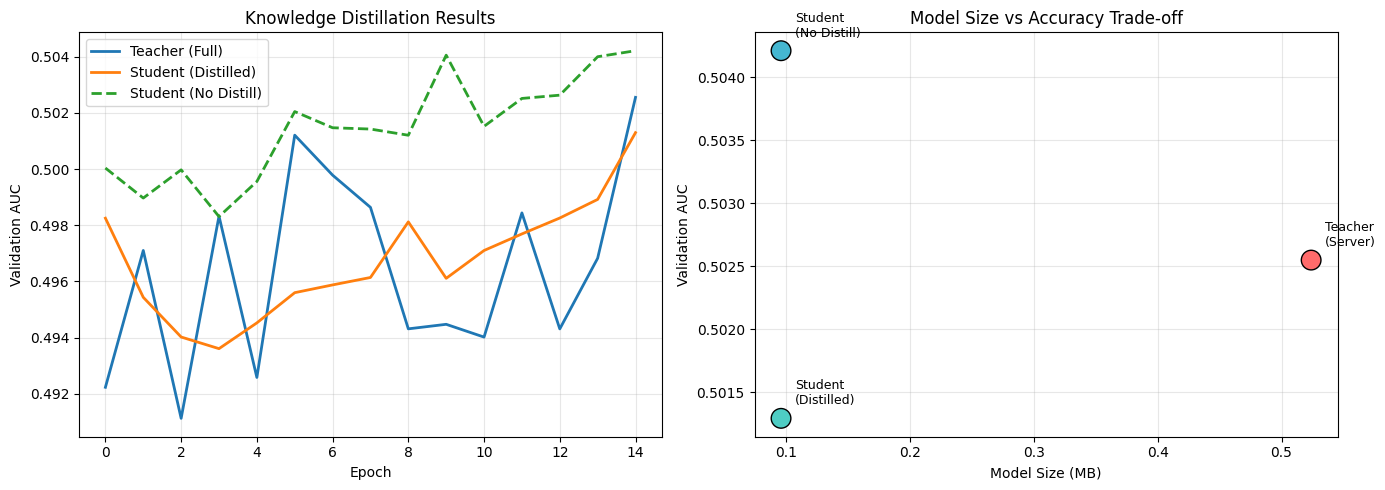

In [5]:
# Compare models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(teacher_history['val_auc'], label='Teacher (Full)', linewidth=2)
axes[0].plot(student_distill_history['val_auc'], label='Student (Distilled)', linewidth=2)
axes[0].plot(student_nodistill_history['val_auc'], label='Student (No Distill)', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation AUC')
axes[0].set_title('Knowledge Distillation Results')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Size vs accuracy
models = ['Teacher\n(Server)', 'Student\n(Distilled)', 'Student\n(No Distill)']
sizes = [get_model_size(teacher), get_model_size(student), get_model_size(student_nodistill)]
aucs = [teacher_history['val_auc'][-1], student_distill_history['val_auc'][-1],
        student_nodistill_history['val_auc'][-1]]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
scatter = axes[1].scatter(sizes, aucs, s=200, c=colors, edgecolors='black', linewidths=1, zorder=5)
for i, name in enumerate(models):
    axes[1].annotate(name, (sizes[i], aucs[i]), textcoords='offset points',
                     xytext=(10, 10), fontsize=9)
axes[1].set_xlabel('Model Size (MB)')
axes[1].set_ylabel('Validation AUC')
axes[1].set_title('Model Size vs Accuracy Trade-off')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Weight Pruning

Pruning removes unimportant weights to reduce model size:

$$w_{ij}^{\text{pruned}} = \begin{cases} w_{ij} & \text{if } |w_{ij}| > \theta \\ 0 & \text{otherwise} \end{cases}$$

> **⚠️ Common Pitfall:** Aggressive pruning without fine-tuning destroys model quality.
> Always fine-tune after pruning to recover lost accuracy.

Sparsity: 0%, AUC: 0.5025
Sparsity: 10%, AUC: 0.5013
Sparsity: 20%, AUC: 0.5028


Sparsity: 30%, AUC: 0.5008
Sparsity: 40%, AUC: 0.5044
Sparsity: 50%, AUC: 0.5016


Sparsity: 60%, AUC: 0.5033
Sparsity: 70%, AUC: 0.5023
Sparsity: 80%, AUC: 0.5032


Sparsity: 90%, AUC: 0.5092


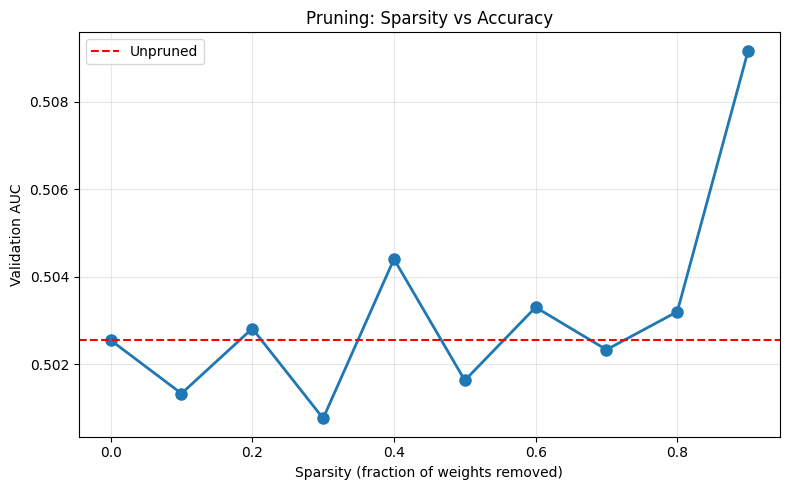

In [6]:
def magnitude_prune(model, sparsity=0.5):
    """Apply magnitude-based pruning to all linear layers."""
    pruned_model = copy.deepcopy(model)
    total_params = 0
    pruned_params = 0
    
    for name, param in pruned_model.named_parameters():
        if 'weight' in name and len(param.shape) == 2:  # Linear layers
            total_params += param.numel()
            threshold = torch.quantile(param.abs().flatten(), sparsity)
            mask = param.abs() > threshold
            param.data *= mask.float()
            pruned_params += (~mask).sum().item()
    
    actual_sparsity = pruned_params / total_params if total_params > 0 else 0
    return pruned_model, actual_sparsity

def evaluate_model_auc(model, val_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for users, items, labels in val_loader:
            pred = torch.sigmoid(model(users, items))
            all_preds.extend(pred.numpy())
            all_labels.extend(labels.numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    pos = all_preds[all_labels == 1]
    neg = all_preds[all_labels == 0]
    return np.mean([np.mean(pos > n) for n in neg]) if len(pos) > 0 and len(neg) > 0 else 0.5

# Test different sparsity levels
sparsity_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
pruning_results = []

for sp in sparsity_levels:
    pruned, actual_sp = magnitude_prune(teacher, sp)
    auc = evaluate_model_auc(pruned, val_loader)
    pruning_results.append({'sparsity': sp, 'actual_sparsity': actual_sp, 'auc': auc})
    print(f"Sparsity: {sp:.0%}, AUC: {auc:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([r['sparsity'] for r in pruning_results],
        [r['auc'] for r in pruning_results], 'o-', linewidth=2, markersize=8)
ax.axhline(y=teacher_history['val_auc'][-1], color='red', linestyle='--', label='Unpruned')
ax.set_xlabel('Sparsity (fraction of weights removed)')
ax.set_ylabel('Validation AUC')
ax.set_title('Pruning: Sparsity vs Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Quantization

Quantization reduces precision from float32 to int8, reducing model size by ~4x.

$$w_{\text{int8}} = \text{round}\left(\frac{w - w_{\min}}{w_{\max} - w_{\min}} \cdot 255\right)$$

> **🔑 Pro Tip:** Post-training quantization is quick but lossy. Quantization-aware training
> (QAT) simulates quantization during training for better accuracy.

2-bit: AUC=0.4954, Size=0.03MB
4-bit: AUC=0.4981, Size=0.07MB
6-bit: AUC=0.5030, Size=0.10MB
8-bit: AUC=0.5024, Size=0.13MB


16-bit: AUC=0.5025, Size=0.26MB
32-bit: AUC=0.5025, Size=0.52MB


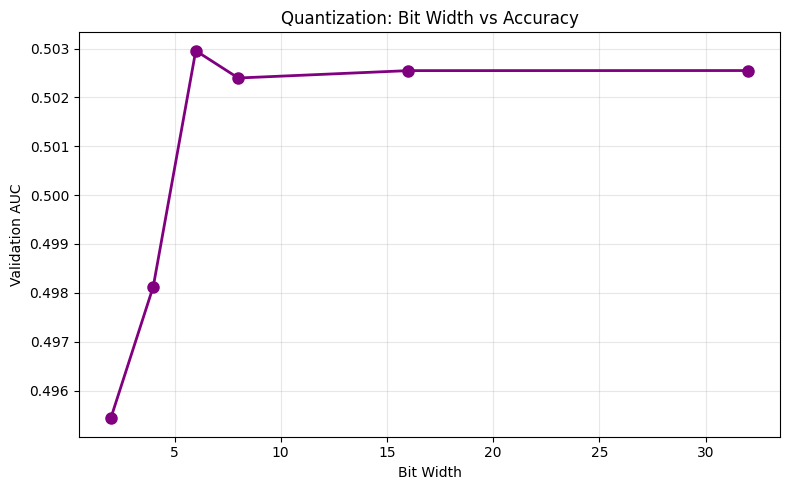

In [7]:
def simulate_quantization(model, n_bits=8):
    """Simulate quantization effects on model weights."""
    quantized = copy.deepcopy(model)
    n_levels = 2 ** n_bits
    
    for param in quantized.parameters():
        w_min = param.data.min()
        w_max = param.data.max()
        if w_max - w_min > 0:
            # Simulate quantize -> dequantize
            scale = (w_max - w_min) / (n_levels - 1)
            param.data = torch.round((param.data - w_min) / scale) * scale + w_min
    
    return quantized

# Test different bit widths
bit_widths = [2, 4, 6, 8, 16, 32]
quant_results = []

for bits in bit_widths:
    if bits == 32:
        q_model = teacher  # No quantization
    else:
        q_model = simulate_quantization(teacher, n_bits=bits)
    auc = evaluate_model_auc(q_model, val_loader)
    size_ratio = bits / 32.0
    quant_results.append({'bits': bits, 'auc': auc, 'size_ratio': size_ratio})
    print(f"{bits}-bit: AUC={auc:.4f}, Size={size_ratio*get_model_size(teacher):.2f}MB")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([r['bits'] for r in quant_results],
        [r['auc'] for r in quant_results], 'o-', linewidth=2, markersize=8, color='purple')
ax.set_xlabel('Bit Width')
ax.set_ylabel('Validation AUC')
ax.set_title('Quantization: Bit Width vs Accuracy')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. On-Device Personalization

After deploying a compressed model on-device, we can **locally fine-tune** it
using the user's recent interactions — without sending data to the server.

> **💡 Concept:** On-device personalization only updates user-specific parameters
> (user embedding, adapter layers). This is fast, private, and adapts to individual preferences.

In [8]:
def on_device_personalize(model, user_id, user_interactions, n_steps=20, lr=0.01):
    """Fine-tune user embedding on-device using local data."""
    personalized = copy.deepcopy(model)
    
    # Freeze everything except user embeddings
    for name, param in personalized.named_parameters():
        if 'user_emb' not in name:
            param.requires_grad = False
    
    optimizer = torch.optim.SGD(
        filter(lambda p: p.requires_grad, personalized.parameters()), lr=lr
    )
    criterion = nn.BCEWithLogitsLoss()
    
    # Local training
    users = torch.tensor([user_id] * len(user_interactions), dtype=torch.long)
    items = torch.tensor([d[1] for d in user_interactions], dtype=torch.long)
    labels = torch.tensor([d[2] for d in user_interactions], dtype=torch.float)
    
    losses = []
    for step in range(n_steps):
        pred = personalized(users, items)
        loss = criterion(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    return personalized, losses

# Simulate on-device personalization for a specific user
target_user = 0
user_data = [(d[0], d[1], d[2]) for d in interactions if d[0] == target_user][:30]
train_data = user_data[:20]
test_data = user_data[20:]

# Before personalization
student.eval()
before_preds = []
with torch.no_grad():
    for u, i, l in test_data:
        pred = torch.sigmoid(student(torch.tensor([u]), torch.tensor([i])))
        before_preds.append(pred.item())

# After personalization
personalized_model, p_losses = on_device_personalize(student, target_user, train_data)
personalized_model.eval()
after_preds = []
with torch.no_grad():
    for u, i, l in test_data:
        pred = torch.sigmoid(personalized_model(torch.tensor([u]), torch.tensor([i])))
        after_preds.append(pred.item())

print(f"User {target_user}: {len(train_data)} training interactions, {len(test_data)} test")
print(f"Before personalization - predictions: {[f'{p:.3f}' for p in before_preds[:5]]}")
print(f"After personalization  - predictions: {[f'{p:.3f}' for p in after_preds[:5]]}")
print(f"True labels: {[d[2] for d in test_data[:5]]}")

User 0: 20 training interactions, 10 test
Before personalization - predictions: ['0.514', '0.464', '0.745', '0.457', '0.623']
After personalization  - predictions: ['0.514', '0.463', '0.745', '0.457', '0.623']
True labels: [1, 1, 1, 0, 1]


## 7. Federated Learning for Recommendation

Federated learning trains a global model by aggregating local updates from devices,
without sharing raw user data.

$$\theta^{(t+1)} = \theta^{(t)} + \frac{1}{|S|} \sum_{k \in S} (\theta_k^{(t)} - \theta^{(t)})$$

where $S$ is the set of participating devices and $\theta_k$ are locally updated parameters.

Round 2/10 - AUC: 0.4985


Round 4/10 - AUC: 0.4985


Round 6/10 - AUC: 0.4985


Round 8/10 - AUC: 0.4986


Round 10/10 - AUC: 0.4986


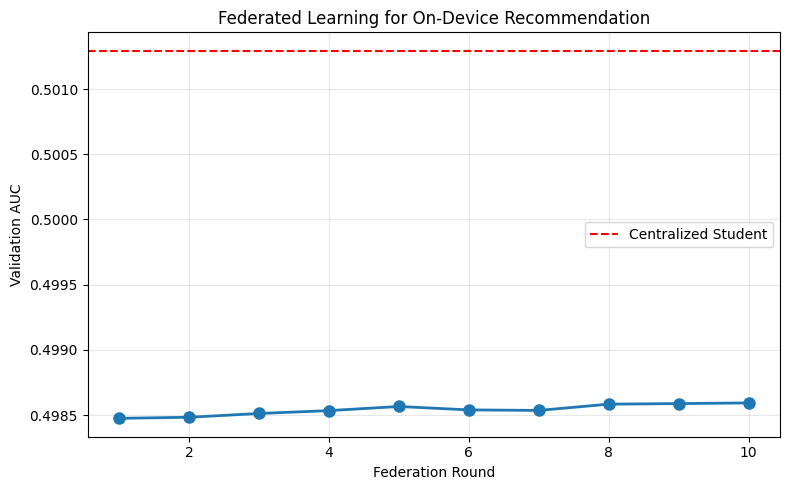

In [9]:
def federated_training(global_model, user_data_dict, n_rounds=10,
                        n_local_steps=5, local_lr=0.01, frac_clients=0.3):
    """Simplified Federated Averaging (FedAvg)."""
    history = []
    all_users = list(user_data_dict.keys())
    
    for round_idx in range(n_rounds):
        # Select subset of clients
        n_clients = max(1, int(len(all_users) * frac_clients))
        selected = np.random.choice(all_users, n_clients, replace=False)
        
        # Collect local updates
        local_models = []
        for user_id in selected:
            local_model = copy.deepcopy(global_model)
            optimizer = torch.optim.SGD(local_model.parameters(), lr=local_lr)
            criterion = nn.BCEWithLogitsLoss()
            
            local_data = user_data_dict[user_id]
            if len(local_data) < 2:
                continue
            
            users = torch.tensor([d[0] for d in local_data], dtype=torch.long)
            items = torch.tensor([d[1] for d in local_data], dtype=torch.long)
            labels = torch.tensor([d[2] for d in local_data], dtype=torch.float)
            
            local_model.train()
            for _ in range(n_local_steps):
                pred = local_model(users, items)
                loss = criterion(pred, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            local_models.append(local_model)
        
        # Aggregate (FedAvg)
        if local_models:
            with torch.no_grad():
                for param_idx, global_param in enumerate(global_model.parameters()):
                    avg = torch.zeros_like(global_param)
                    for local_model in local_models:
                        local_params = list(local_model.parameters())
                        avg += local_params[param_idx].data
                    avg /= len(local_models)
                    global_param.data = avg
        
        # Evaluate
        auc = evaluate_model_auc(global_model, val_loader)
        history.append(auc)
        if (round_idx + 1) % 2 == 0:
            print(f"Round {round_idx+1}/{n_rounds} - AUC: {auc:.4f}")
    
    return history

# Prepare per-user data
user_data_dict = defaultdict(list)
for d in interactions[:split]:
    user_data_dict[d[0]].append(d)

fed_model = StudentRecModel()
fed_history = federated_training(fed_model, user_data_dict, n_rounds=10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(fed_history)+1), fed_history, 'o-', linewidth=2, markersize=8)
ax.axhline(y=student_distill_history['val_auc'][-1], color='red', linestyle='--',
           label='Centralized Student')
ax.set_xlabel('Federation Round')
ax.set_ylabel('Validation AUC')
ax.set_title('Federated Learning for On-Device Recommendation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🏋️ Exercise 1: Implement Latency Benchmarking

Benchmark inference latency for teacher, student, pruned, and quantized models.
Create a Pareto plot of latency vs accuracy.

In [10]:
# TODO: Benchmark inference latency
def benchmark_latency(model, n_warmup=10, n_runs=100):
    """Measure average inference latency."""
    # TODO:
    # 1. Create dummy input
    # 2. Warm up
    # 3. Time n_runs inferences
    # 4. Return average latency in ms
    pass

# TODO: Create Pareto plot of latency vs AUC for all model variants
print("Exercise 1: Implement latency benchmarking")

Exercise 1: Implement latency benchmarking


## 🏋️ Exercise 2: Implement Split Inference

Design a split inference system where the device runs a lightweight personalization
layer and the server handles the heavy base model.

In [11]:
# TODO: Implement split inference
class ServerModel(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Heavy base model (item embeddings + feature extraction)
        pass

class DeviceModel(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Lightweight personalization (user embedding + adapter)
        pass

# TODO: Implement the split inference pipeline
print("Exercise 2: Implement split inference")

Exercise 2: Implement split inference


## 🏋️ Exercise 3: Implement Differential Privacy in Federated Learning

Add noise to local model updates to provide differential privacy guarantees.

In [12]:
# TODO: Add differential privacy to federated learning
def dp_federated_training(global_model, user_data_dict, noise_scale=0.1,
                           clip_norm=1.0, n_rounds=10):
    """Federated learning with differential privacy."""
    # TODO:
    # 1. After local training, clip the update norm
    # 2. Add calibrated Gaussian noise
    # 3. Aggregate noisy updates
    pass

print("Exercise 3: Implement DP federated learning")

Exercise 3: Implement DP federated learning


## Summary

In this notebook, we explored on-device and edge recommendation:

1. **Knowledge distillation**: Training a compact student from a large teacher model
2. **Pruning**: Removing unimportant weights for smaller model size
3. **Quantization**: Reducing precision for 4x size reduction
4. **On-device personalization**: Local fine-tuning of user embeddings
5. **Federated learning**: Training global models without sharing user data

### Key Takeaways

- Knowledge distillation is the most effective single compression technique
- Combining pruning + quantization + distillation achieves the best compression
- On-device personalization adapts to individual users privately
- Federated learning enables collaborative model improvement without data sharing
- Always benchmark latency alongside accuracy for deployment decisions